In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
sales = pd.read_csv("../data/cleaned/sales_daily_clean.csv")
sku = pd.read_csv("../data/cleaned/sku_master_clean.csv")
calendar = pd.read_csv("../data/cleaned/calendar_clean.csv")
inventory = pd.read_csv("../data/cleaned/inventory_snapshots_clean.csv")

In [30]:
print("SKU:", sku.shape)
print("Sales:", sales.shape)
print("Inventory:", inventory.shape)
print("Calendar:", calendar.shape)

SKU: (50, 9)
Sales: (36550, 6)
Inventory: (1200, 8)
Calendar: (731, 11)


#### SKU/Product Analysis

In [31]:
sku["Category"].value_counts()

Category
Furniture     10
Home Decor    10
Kitchen       10
Lighting      10
Storage       10
Name: count, dtype: int64

In [32]:
sku["Subcategory"].value_counts()

Subcategory
Chair        5
Table        5
Cushion      5
Cookware     5
Lamp         5
Shelf        5
Cabinet      5
Rug          5
Organizer    5
Sofa         5
Name: count, dtype: int64

In [33]:
sku[["Cost_Price", "Selling_Price", "Gross_Margin_Per_Unit"]].describe()

,Cost_Price,Selling_Price,Gross_Margin_Per_Unit
count,50.000000,50.000000,50.000000
mean,3770.729400,5892.663800,2121.934400
std,2025.786477,3170.598793,3784.884812
min,307.060000,663.460000,-5484.320000
25%,1936.910000,3502.567500,-579.570000
50%,3836.845000,5649.795000,1790.025000
75%,5514.770000,8506.780000,4846.322500
max,7748.200000,11642.450000,10224.930000


In [34]:
sku[sku["Negative_Margin"] == True]

,SKU,Product_Name,Category,Subcategory,Launch_Date,Cost_Price,Selling_Price,Gross_Margin_Per_Unit,Negative_Margin
1,SKU002,Product 002,Home Decor,Table,2024-05-01,3867.09,3805.69,-61.40,True
6,SKU007,Product 007,Home Decor,Cabinet,2022-04-05,7748.20,5114.09,-2634.11,True
8,SKU009,Product 009,Lighting,Organizer,2022-08-10,3121.06,2336.89,-784.17,True
9,SKU010,Product 010,Storage,Sofa,2022-04-14,3889.06,663.46,-3225.60,True
10,SKU011,Product 011,Furniture,Chair,2023-08-03,1718.40,1444.56,-273.84,True
15,SKU016,Product 016,Furniture,Shelf,2024-05-14,3637.93,2166.82,-1471.11,True
17,SKU018,Product 018,Kitchen,Rug,2022-05-21,5677.05,5575.41,-101.64,True
19,SKU020,Product 020,Storage,Sofa,2023-05-11,6700.01,3897.54,-2802.47,True
22,SKU023,Product 023,Kitchen,Cushion,2022-07-20,2484.54,1416.74,-1067.80,True
23,SKU024,Product 024,Lighting,Cookware,2024-10-16,5539.34,1768.87,-3770.47,True


#### Sales & Demand Analysis

In [36]:
sales[["Units_Sold", "Revenue", "Price"]].describe()

,Units_Sold,Revenue,Price
count,36550.000000,36550.00000,36550.000000
mean,14.003010,84707.43385,5892.663800
std,8.467305,76534.63044,3138.775609
min,0.000000,0.00000,663.460000
25%,7.000000,27643.70000,3484.090000
50%,13.000000,56125.90000,5649.795000
75%,20.000000,127954.32000,8516.600000
max,56.000000,546977.00000,11642.450000


In [37]:
print("Total Units Sold:", sales["Units_Sold"].sum())

Total Units Sold: 511810


In [38]:
print("Total Revenue:", sales["Revenue"].sum())

Total Revenue: 3096056707.2199993


In [39]:
top_skus = (sales.groupby("SKU")["Units_Sold"].sum().sort_values(ascending=False))
print(top_skus.head(10))

SKU
SKU012    19067
SKU045    18612
SKU018    18450
SKU049    18373
SKU037    18155
SKU007    18129
SKU027    17717
SKU042    16616
SKU026    16535
SKU043    16276
Name: Units_Sold, dtype: int64


In [40]:
sales["Date"] = pd.to_datetime(sales["Date"])
monthly_sales = (sales.groupby(sales["Date"].dt.to_period("M"))["Units_Sold"].sum())
print(monthly_sales)

Date
2024-01    20961
2024-02    21333
2024-03    26791
2024-04    24177
2024-05    24402
2024-06    24506
2024-07    21118
2024-08    19351
2024-09    18723
2024-10    17173
2024-11    18660
2024-12    19390
2025-01    20938
2025-02    20944
2025-03    26757
2025-04    23959
2025-05    24636
2025-06    24110
2025-07    20998
2025-08    19403
2025-09    18408
2025-10    17217
2025-11    18717
2025-12    19138
Freq: M, Name: Units_Sold, dtype: int64


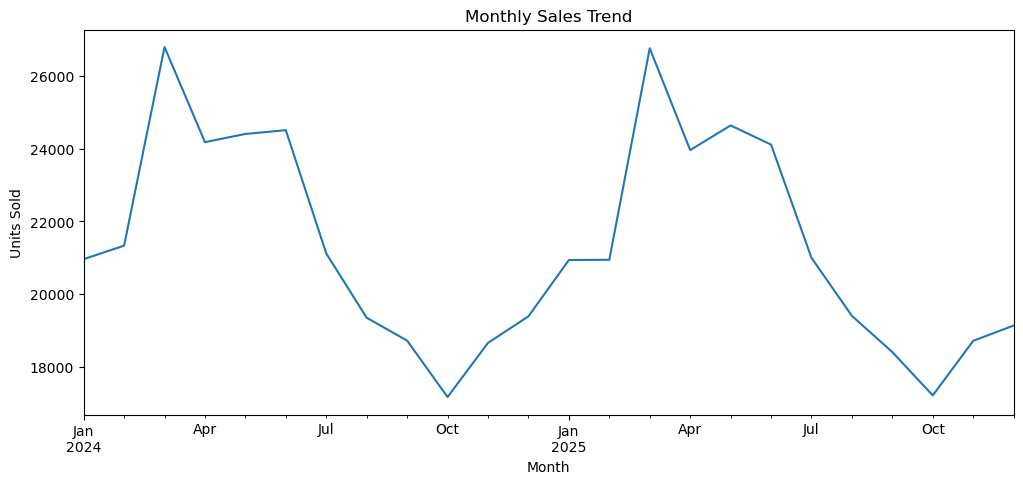

In [41]:
monthly_sales.plot(kind="line", figsize=(12,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.show()

#### Inventory Analysis

In [43]:
inventory.describe()

,Current_Stock,On_Order,Lead_Time_Days,Safety_Stock,Reorder_Point,Inventory_Value
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1.200000e+03
mean,308.706667,212.736667,8.494167,85.278333,217.670833,1.289199e+06
std,242.261538,206.450673,3.528268,63.005057,157.867167,1.326472e+06
min,5.000000,0.000000,3.000000,5.000000,10.000000,2.444200e+03
25%,127.000000,61.000000,5.000000,41.000000,101.000000,3.239485e+05
50%,249.500000,153.500000,9.000000,71.000000,183.000000,8.231890e+05
75%,435.000000,303.000000,12.000000,114.250000,301.000000,1.851320e+06
max,1844.000000,1706.000000,14.000000,413.000000,1041.000000,1.041211e+07


In [44]:
inventory["Below_Reorder_Point"] = (
    inventory["Current_Stock"] < inventory["Reorder_Point"]
)

In [45]:
inventory["Below_Reorder_Point"].value_counts()

Below_Reorder_Point
False    869
True     331
Name: count, dtype: int64

#### Calendar & Seasonality Analysis

In [46]:
sales["Date"] = pd.to_datetime(sales["Date"])
calendar["date"] = pd.to_datetime(calendar["date"])

sales_calendar = sales.merge(calendar, left_on="Date", right_on="date", how="left")

In [47]:
sales_calendar.groupby("month")["Units_Sold"].mean()

month
1     13.515806
2     14.834035
3     17.273548
4     16.045333
5     15.818710
6     16.205333
7     13.585806
8     12.501290
9     12.377000
10    11.093548
11    12.459000
12    12.428387
Name: Units_Sold, dtype: float64

In [48]:
sales_calendar.groupby("day_of_week")["Units_Sold"].mean()

day_of_week
Friday       13.185962
Monday       13.034286
Saturday     16.279231
Sunday       16.379808
Thursday     13.114038
Tuesday      13.017524
Wednesday    13.038286
Name: Units_Sold, dtype: float64

In [49]:
sales_calendar.groupby("is_weekend")["Units_Sold"].mean()

is_weekend
0    13.077744
1    16.329519
Name: Units_Sold, dtype: float64

In [50]:
sales_calendar.groupby("season")["Units_Sold"].mean()

season
Autumn     11.765082
Monsoon    12.826196
Spring     16.669508
Summer     16.008852
Winter     13.558453
Name: Units_Sold, dtype: float64

In [51]:
sales_calendar.groupby("is_holiday")["Units_Sold"].mean()

is_holiday
0    14.023402
1    12.160000
Name: Units_Sold, dtype: float64

#### Sales ↔ Inventory Relationship

In [52]:
sku_sales = (sales.groupby("SKU")["Units_Sold"].sum().reset_index())

In [54]:
sku_inventory = (inventory.groupby("SKU")["Current_Stock"].mean().reset_index())

In [55]:
sales_inventory = sku_sales.merge(sku_inventory, on="SKU",how="left")

In [57]:
sales_inventory.head()

,SKU,Units_Sold,Current_Stock
0,SKU001,10502,640.291667
1,SKU002,7412,461.958333
2,SKU003,4214,272.000000
3,SKU004,3380,328.416667
4,SKU005,12196,472.958333


#### Promotion Analysis

In [58]:
sales.groupby("Promotion")["Units_Sold"].mean()

Promotion
0    13.475945
1    18.613067
Name: Units_Sold, dtype: float64

In [59]:
sales.groupby("Promotion")["Revenue"].mean()

Promotion
0     81550.078302
1    112323.770379
Name: Revenue, dtype: float64

#### Outlier Analysis

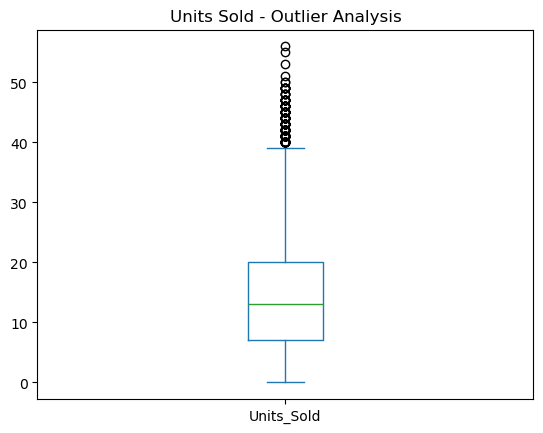

In [60]:
sales["Units_Sold"].plot(kind="box")
plt.title("Units Sold - Outlier Analysis")
plt.show()